# Plant Detection using TensorFlow Object Detection API

This notebook demonstrates training and evaluation of an object detection model
for plant instance detection on the :contentReference[oaicite:0]{index=0} dataset.

We fine-tune a pre-trained SSD model:
- Model: SSD MobileNet V2 (320×320)
- Framework: TensorFlow Object Detection API (TF 2.11)
- Task: Crop vs Weed detection

The notebook covers:
1. Environment setup
2. Dataset loading
3. Model configuration
4. Training and evaluation
5. Qualitative inference results

## Environment Setup

This experiment is designed for:
- Python 3.10
- TensorFlow 2.11
- CUDA-enabled GPU

On Kaggle:
Enable "Pin to original environment" to avoid version drift.

In [1]:
!python -V

Python 3.10.10


In [2]:
!pip install --no-cache-dir --no-deps \
  tf_slim \
  pycocotools \
  lvis \
  contextlib2 \
  gin-config \
  tf-models-official==2.13.2 \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-femfdypk
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-femfdypk
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit bf76c8554e035600333b5d117da076e7404c62c0
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.5/472.5 kB 65.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 290.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 186.1 MB/s eta 0:00:00
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1798535 sha256=ead8579de119e022659d4be2b10203a6eec8f2fb210c67d2062da6b205148c86
  Stored 

In [3]:
from pathlib import Path

EXPERIMENT_ROOT = Path(
    "/kaggle/working"
)

FINETUNE_PATH = (
    EXPERIMENT_ROOT / "finetune"
)

FINETUNE_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

EXPORTS_PATH = (
    EXPERIMENT_ROOT / "exports"
)

MANIFEST_PATH = (
    EXPERIMENT_ROOT / "manifest.json"
)

In [4]:
import tensorflow as tf
import sys
from agri_vision_edge.third_party import setup_tensorflow_models
from agri_vision_edge.experiment import ExperimentManifest

setup_tensorflow_models()

manifest = ExperimentManifest(
    name="binary_ssd_mobilenet_v2_320x320_phenobench",
    task="object_detection",
)

manifest.set_environment(
    platform="kaggle",

    tensorflow=tf.__version__,

    python=sys.version,

    gpu=[
        d.name
        for d in tf.config.list_physical_devices("GPU")
    ],
)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [5]:
from dataclasses import asdict
from agri_vision_edge.experiment import FineTuneConfig

config = FineTuneConfig(
    batch_size = 16,
    learning_rate_base = 0.0015,
    warmup_learning_rate = 0.0003,

    num_steps = 20_000,

    warmup_steps = 1000,

    early_stopping_patience = 50,
    early_stopping_min_delta = 0.0,

    image_size = 320,

    # Anchor tuning
    anchor_min_scale = 0.01,
    anchor_max_scale = 0.25,

    anchor_aspect_ratios = (
        1.0,
        2.0,
        0.5,
    ),

    matched_threshold = 0.8,
    unmatched_threshold = 0.35,

    use_random_crop = True,

    nms_score_threshold = 0.05,

    nms_iou_threshold = 0.5,

    max_detections_per_class = 60,
    max_total_detections = 60,
)

manifest.add_stage(
    "finetune",
    config=asdict(config),
)

'done'

'done'

## Dataset

We use preprocessed TFRecord files derived from :contentReference[oaicite:1]{index=1}.

Additionally, raw images are used for qualitative evaluation.

In [6]:
manifest.set_dataset(
    name="phenobench",

    train_split="train",

    validation_split="val",

    num_classes=2,
)

dataset_dir = Path("/kaggle/input/datasets/freimutdiener/binary-object-detection-phenobench-dataset")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
train_record = dataset_dir / "train.record"
val_record = dataset_dir / "val.record"

test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## Model Configuration

We fine-tune a pre-trained SSD model:
- Backbone: MobileNetV2
- Feature extractor: FPNLite
- Input size: 320×320

We adapt:
- number of classes
- learning rate schedule
- dataset paths

In [7]:
model_name = "ssd_mobilenet_v2_320x320_coco17_tpu-8"

manifest.set_checkpoint(
    model_name=model_name,
    pretrained_dataset="coco17",

    source="tensorflow_model_zoo",
)

MODEL_DIR = (Path("/kaggle/input/models/freimutdiener/"
                  "ssd-mobilenet-v2-320x320/tensorflow2/coco17/1")
             / model_name)

In [8]:
PIPELINE_CONFIG = FINETUNE_PATH / "pipeline.config"

from agri_vision_edge.tfod import configure_ssd_pipeline

configure_ssd_pipeline(
    config=config,
    config_path=MODEL_DIR / "pipeline.config",
    output_path=PIPELINE_CONFIG,
    train_record=train_record,
    val_record=val_record,
    label_map=label_map_path,
    checkpoint_path=MODEL_DIR / "checkpoint" / "ckpt-0",
    num_classes=1,
)

manifest.add_artifact(
    "finetune/pipeline.config",

    artifact_type="pipeline_config",

    stage="finetune",
)

## Training

We train for 20,000 steps using fine-tuning from COCO weights.

In [9]:
from object_detection import model_lib_v2

model_lib_v2.train_loop(
  pipeline_config_path=PIPELINE_CONFIG,
  model_dir=str(FINETUNE_PATH),
  checkpoint_every_n=100,
  checkpoint_max_to_keep=3,
  early_stopping_patience=config.early_stopping_patience,
  early_stopping_min_delta=config.early_stopping_min_delta,
)

/opt/conda/lib/python3.10/site-packages/keras/backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Step 100 per-step time 0.458s
{'Loss/classification_loss': 1.5696585,
 'Loss/localization_loss': 2.5762897,
 'Loss/regularization_loss': 0.085091226,
 'Loss/total_loss': 4.2310395,
 'learning_rate': 0.00042000003}

Running evaluation at step 100
creating index...
index created!
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.03s).
Accumulating evaluation results...
DONE (t=0.21s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.0

In [10]:
from agri_vision_edge.tfod.tfod_metrics import load_tfod_best_metrics

BEST_METRICS_JSON = FINETUNE_PATH / "best_metric.json"

metrics = load_tfod_best_metrics(
    BEST_METRICS_JSON
)

manifest.update_stage(
    "finetune",

    metrics={
        "best_coco_metrics":
            metrics.to_dict()
    }
)

manifest.update_stage(
    "finetune",

    artifacts={
        "best_metrics_json":
            "finetune/best_metric.json"
    }
)

## Training Metrics and Learning Curves

The TensorFlow Object Detection API writes training metrics
as TensorBoard event files during optimization.

We parse these logs to generate publication-quality plots
for:

- total training loss
- classification loss
- localization loss
- learning rate schedule
- training throughput

These figures can later be exported directly for inclusion
in reports, presentations, or academic theses.

In [11]:
from agri_vision_edge.evaluation import (
    load_event_scalars,
    available_tags,
    plot_metric_curves,
)

GRAPHS_PATH = FINETUNE_PATH / "graphs"
GRAPHS_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

train_df = load_event_scalars(
    FINETUNE_PATH / "train"
)

eval_df = load_event_scalars(
    FINETUNE_PATH / "eval_on_train"
)

print("Available TensorBoard tags:")
for tag in available_tags(train_df):
    print("-", tag)

Available TensorBoard tags:
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- learning_rate
- steps_per_sec


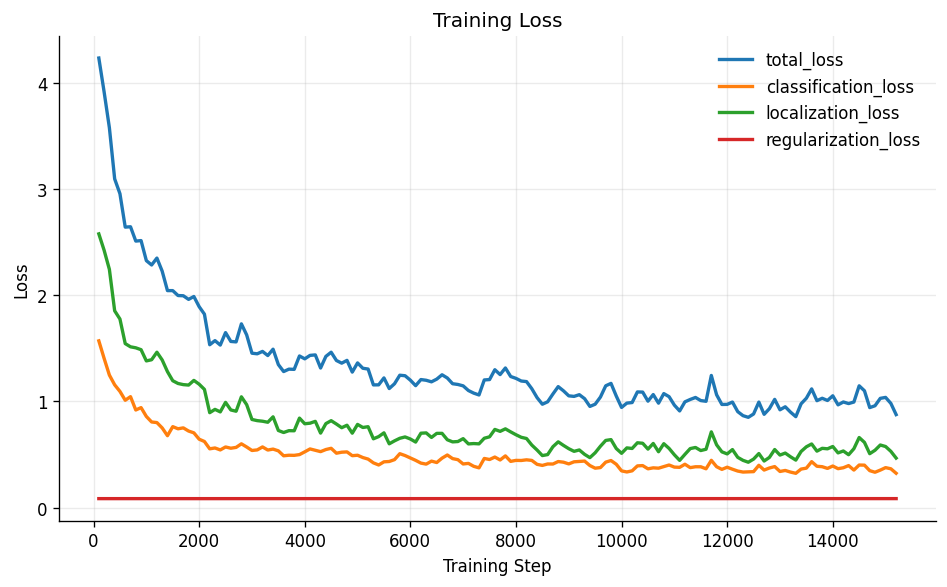

In [12]:
tags = [
    "Loss/total_loss",
    "Loss/classification_loss",
    "Loss/localization_loss",
    "Loss/regularization_loss",
]

fig, ax = plot_metric_curves(
    df=train_df,
    tags=tags,
    title="Training Loss",
    ylabel="Loss",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "training_loss_curves.pdf",
)

display(fig)

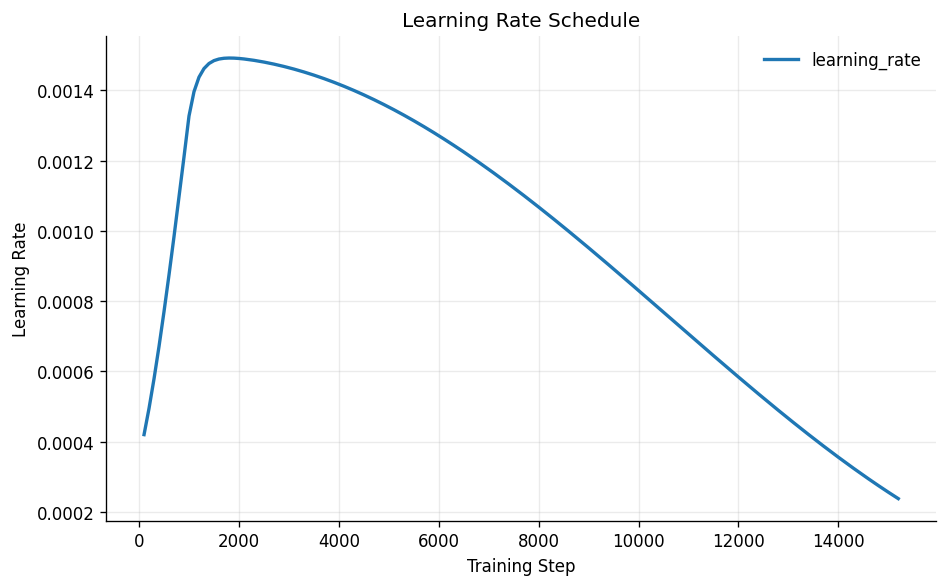

In [13]:

fig, ax = plot_metric_curves(
    df=train_df,
    tags=["learning_rate"],
    title="Learning Rate Schedule",
    ylabel="Learning Rate",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "learning_rate_schedule.pdf",
)

display(fig)

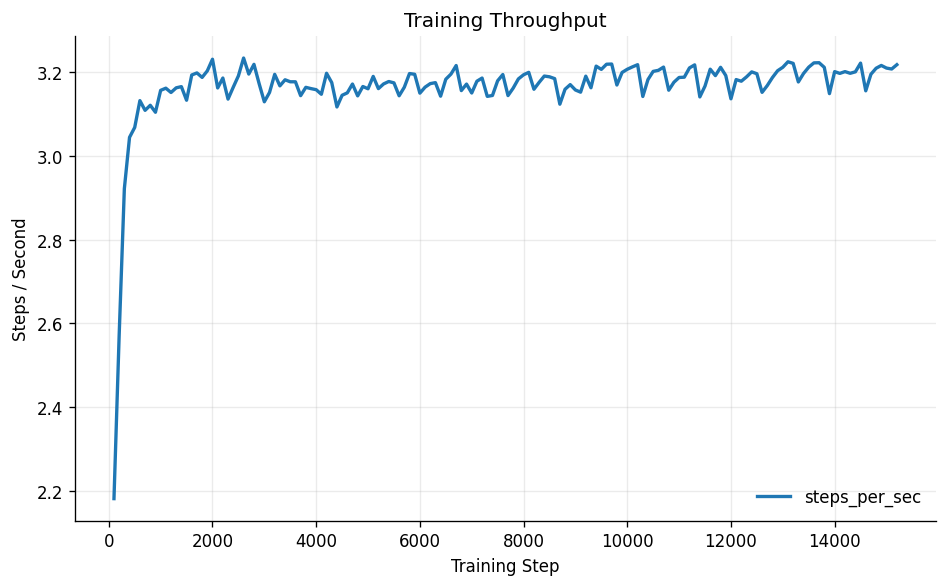

In [14]:
fig, ax = plot_metric_curves(
    df=train_df,
    tags=["steps_per_sec"],
    title="Training Throughput",
    ylabel="Steps / Second",
    smoothing=0.5,
    save_path=GRAPHS_PATH / "training_throughput.pdf",
)

display(fig)

The generated figures are also exported as PDF files:

- `training_loss_curves.pdf`
- `learning_rate_schedule.pdf`
- `training_throughput.pdf`

These vector graphics are suitable for direct inclusion
in scientific publications and LaTeX-based theses.

## Validation Metrics

We evaluate all saved checkpoints using standard
COCO-style object detection metrics.

This enables analysis of:

- convergence behavior
- validation performance evolution
- checkpoint selection
- potential overfitting

In [15]:
print("Available TensorBoard tags:")
for tag in available_tags(eval_df):
    print("-", tag)

Available TensorBoard tags:
- DetectionBoxes_Precision/mAP
- DetectionBoxes_Precision/mAP (large)
- DetectionBoxes_Precision/mAP (medium)
- DetectionBoxes_Precision/mAP (small)
- DetectionBoxes_Precision/mAP@.50IOU
- DetectionBoxes_Precision/mAP@.75IOU
- DetectionBoxes_Recall/AR@1
- DetectionBoxes_Recall/AR@10
- DetectionBoxes_Recall/AR@100
- DetectionBoxes_Recall/AR@100 (large)
- DetectionBoxes_Recall/AR@100 (medium)
- DetectionBoxes_Recall/AR@100 (small)
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- best_eval_metric


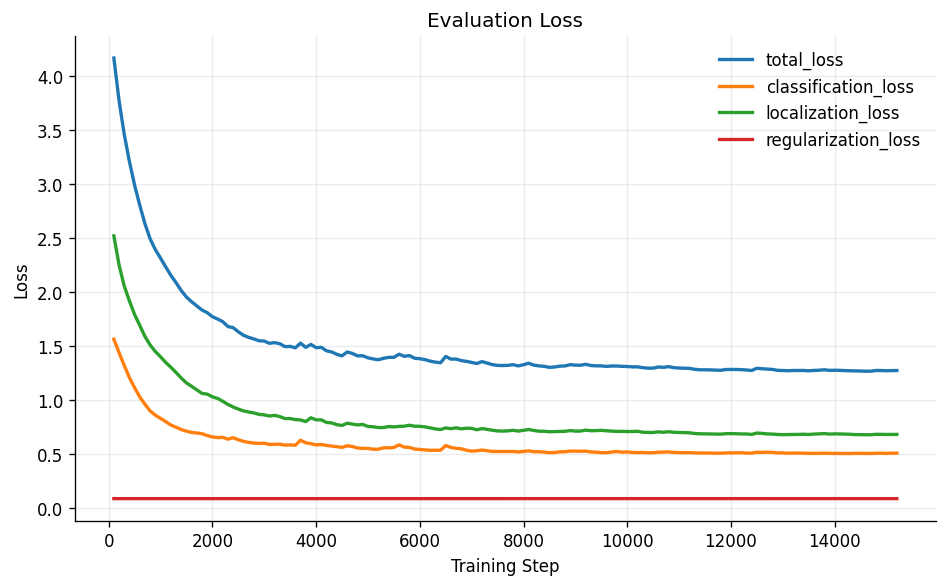

In [16]:
tags = [
    "Loss/total_loss",
    "Loss/classification_loss",
    "Loss/localization_loss",
    "Loss/regularization_loss",
]

fig, ax = plot_metric_curves(
    df=eval_df,
    tags=tags,
    title="Evaluation Loss",
    ylabel="Loss",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_loss_curves.pdf",
)

display(fig)

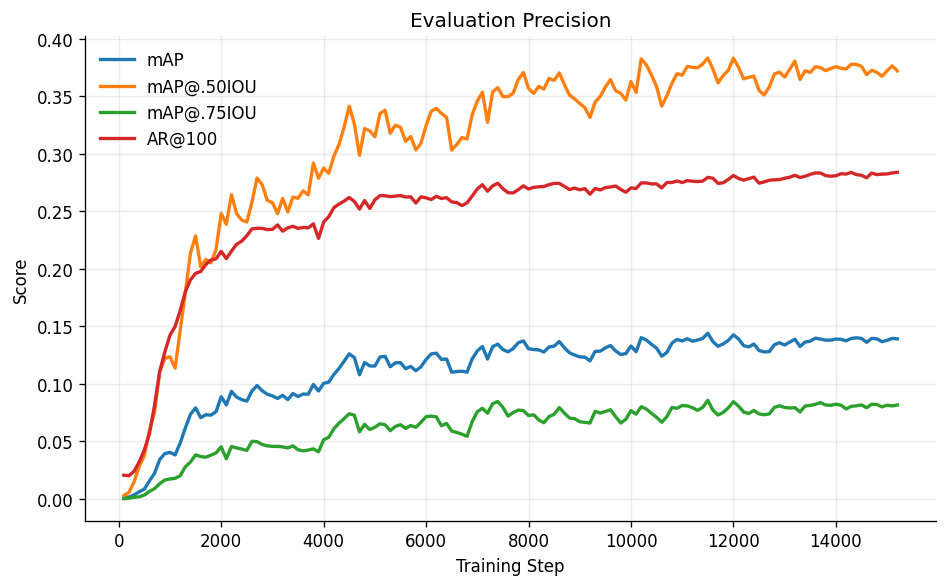

In [17]:
tags = [
    "DetectionBoxes_Precision/mAP",
    "DetectionBoxes_Precision/mAP@.50IOU",
    "DetectionBoxes_Precision/mAP@.75IOU",
    "DetectionBoxes_Recall/AR@100",
]

fig, ax = plot_metric_curves(
    df=eval_df,
    tags=tags,
    title="Evaluation Precision",
    ylabel="Score",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_curves.pdf",
)

display(fig)

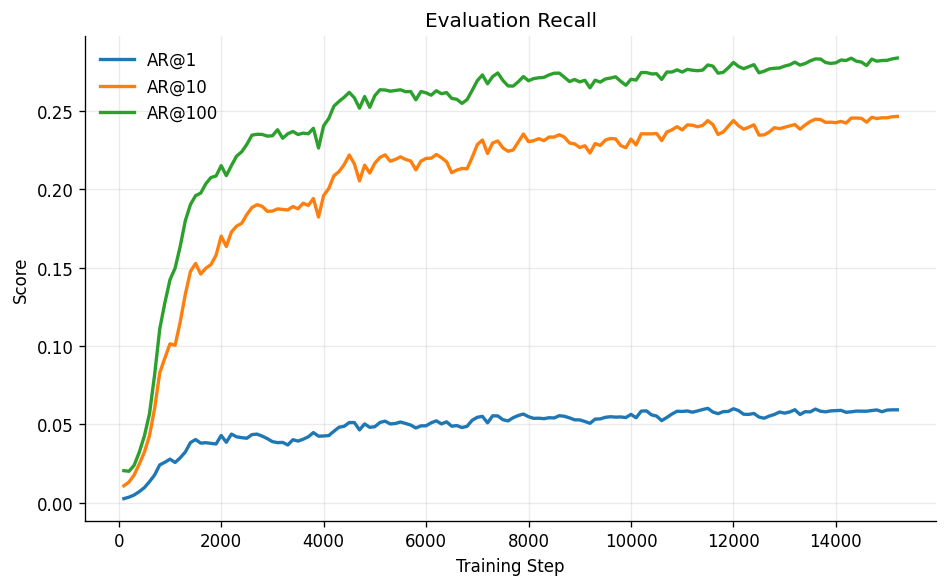

In [18]:
tags = [
    "DetectionBoxes_Recall/AR@1",
    "DetectionBoxes_Recall/AR@10",
    "DetectionBoxes_Recall/AR@100",
]

fig, ax = plot_metric_curves(
    df=eval_df,
    tags=tags,
    title="Evaluation Recall",
    ylabel="Score",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_curves.pdf",
)

display(fig)

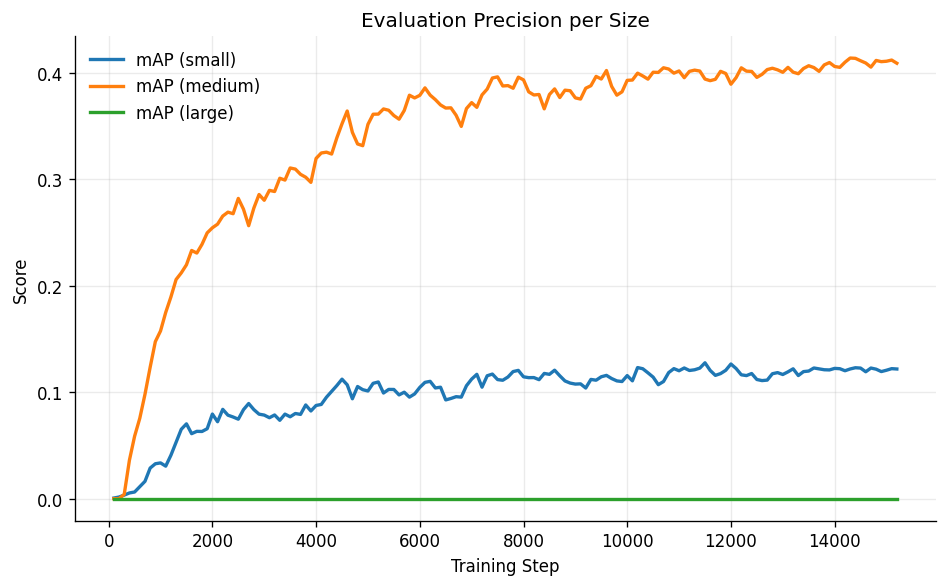

In [19]:
tags = [
    "DetectionBoxes_Precision/mAP (small)",
    "DetectionBoxes_Precision/mAP (medium)",
    "DetectionBoxes_Precision/mAP (large)",
]

fig, ax = plot_metric_curves(
    df=eval_df,
    tags=tags,
    title="Evaluation Precision per Size",
    ylabel="Score",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_size_curves.pdf",
)

display(fig)

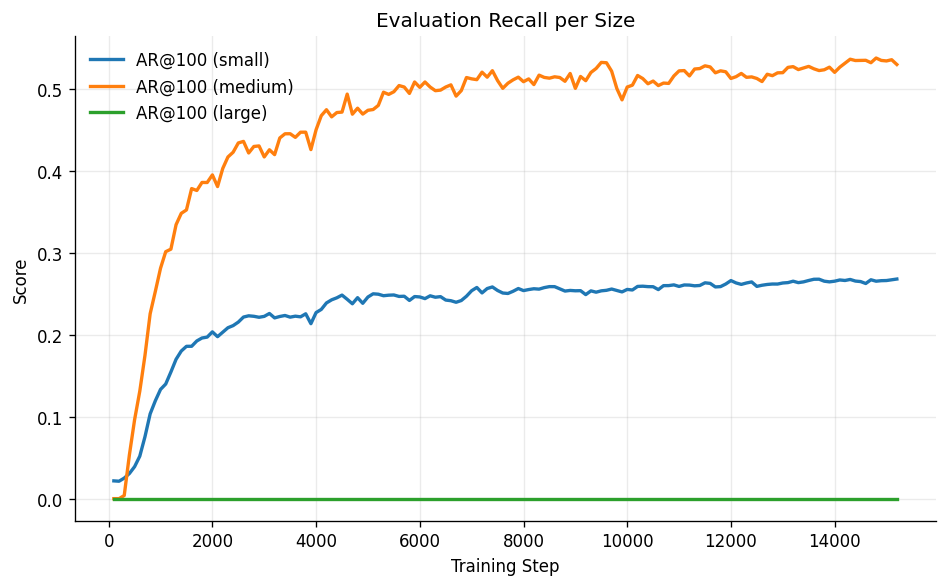

In [20]:
tags = [
    "DetectionBoxes_Recall/AR@100 (small)",
    "DetectionBoxes_Recall/AR@100 (medium)",
    "DetectionBoxes_Recall/AR@100 (large)",
]

fig, ax = plot_metric_curves(
    df=eval_df,
    tags=tags,
    title="Evaluation Recall per Size",
    ylabel="Score",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_size_curves.pdf",
)

display(fig)

In [21]:
manifest.add_artifact(
    "finetune/graphs",

    artifact_type="evaluation_plots",

    stage="finetune",
)

## Model Export

We export the trained model in two formats:

- a standard TensorFlow SavedModel for generic TensorFlow
  inference workflows
- a TensorFlow Lite–compatible export graph for quantization
  and embedded deployment

The TensorFlow Lite export path uses TensorFlow Object
Detection's dedicated TFLite exporter, which rewrites the
graph for improved compatibility with:

- TensorFlow Lite conversion
- post-training quantization
- embedded accelerators
- NPU delegates such as TIM-VX / Teflon

This export path typically reduces dynamic TensorFlow ops
and improves deployment compatibility on edge devices.

In [22]:
from agri_vision_edge.tfod import export_all

export_all(
    pipeline_config_path=str(PIPELINE_CONFIG),

    checkpoint_dir=str(FINETUNE_PATH),

    export_dir=str(EXPORTS_PATH),

    config_override="",
    input_type="image_tensor",

    max_detections=config.max_total_detections,
)

{'saved_model': PosixPath('/kaggle/working/exports/exported_model'),
 'tflite_graph': PosixPath('/kaggle/working/exports/tflite_graph')}

## Register artifacts and save Manifest

In [23]:
manifest.add_artifact(
    "finetune/train",
    artifact_type="tensorboard_train",
    stage="finetune",
)

manifest.add_artifact(
    "finetune/eval_on_train",
    artifact_type="tensorboard_eval",
    stage="finetune",
)

manifest.add_artifact(
    "exports/exported_model",
    artifact_type="tfod_exported_model",
    stage="finetune",
)

manifest.add_artifact(
    "exports/tflite_graph",
    artifact_type="tflite_graph",
    stage="finetune",
)

manifest.save(MANIFEST_PATH)

## Qualitative Evaluation

We visualize predictions on unseen test images.

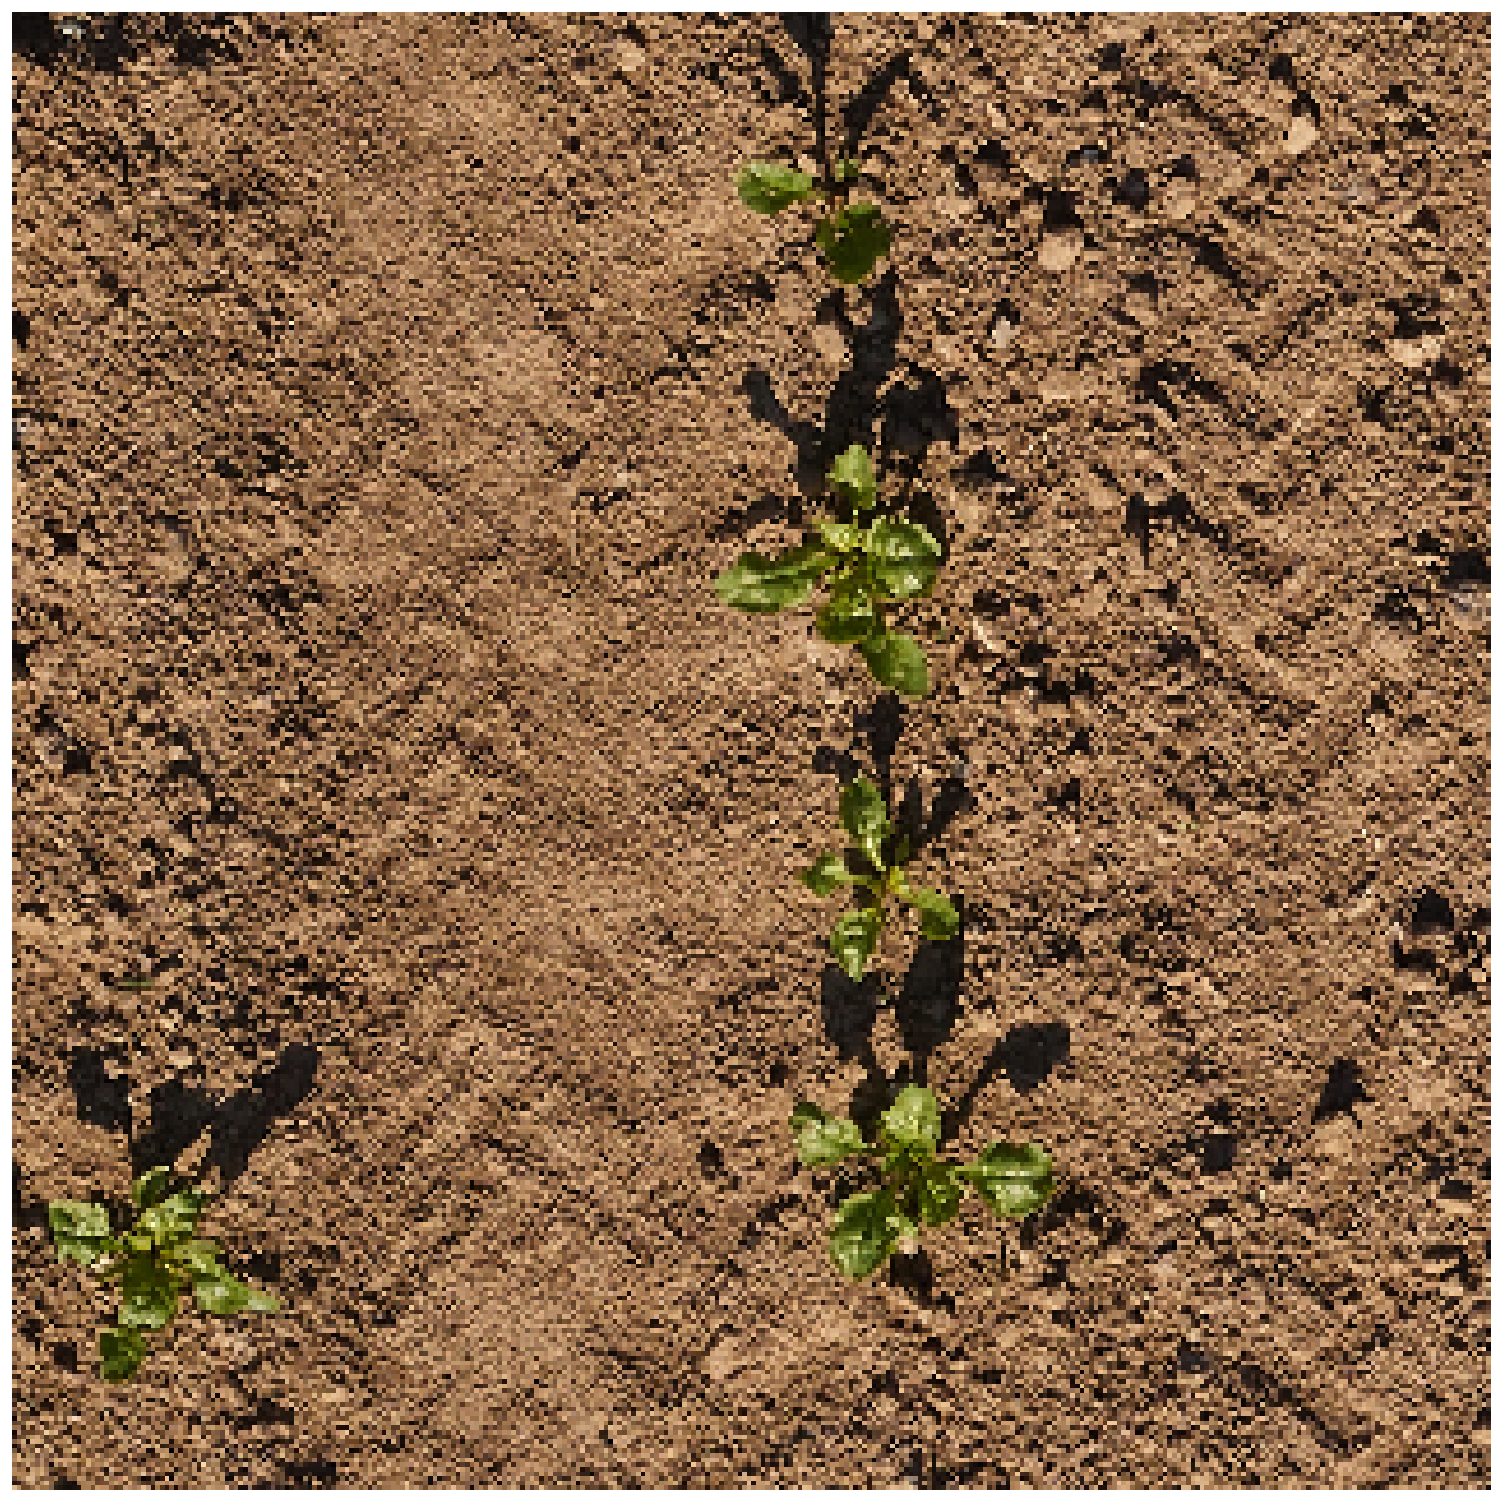

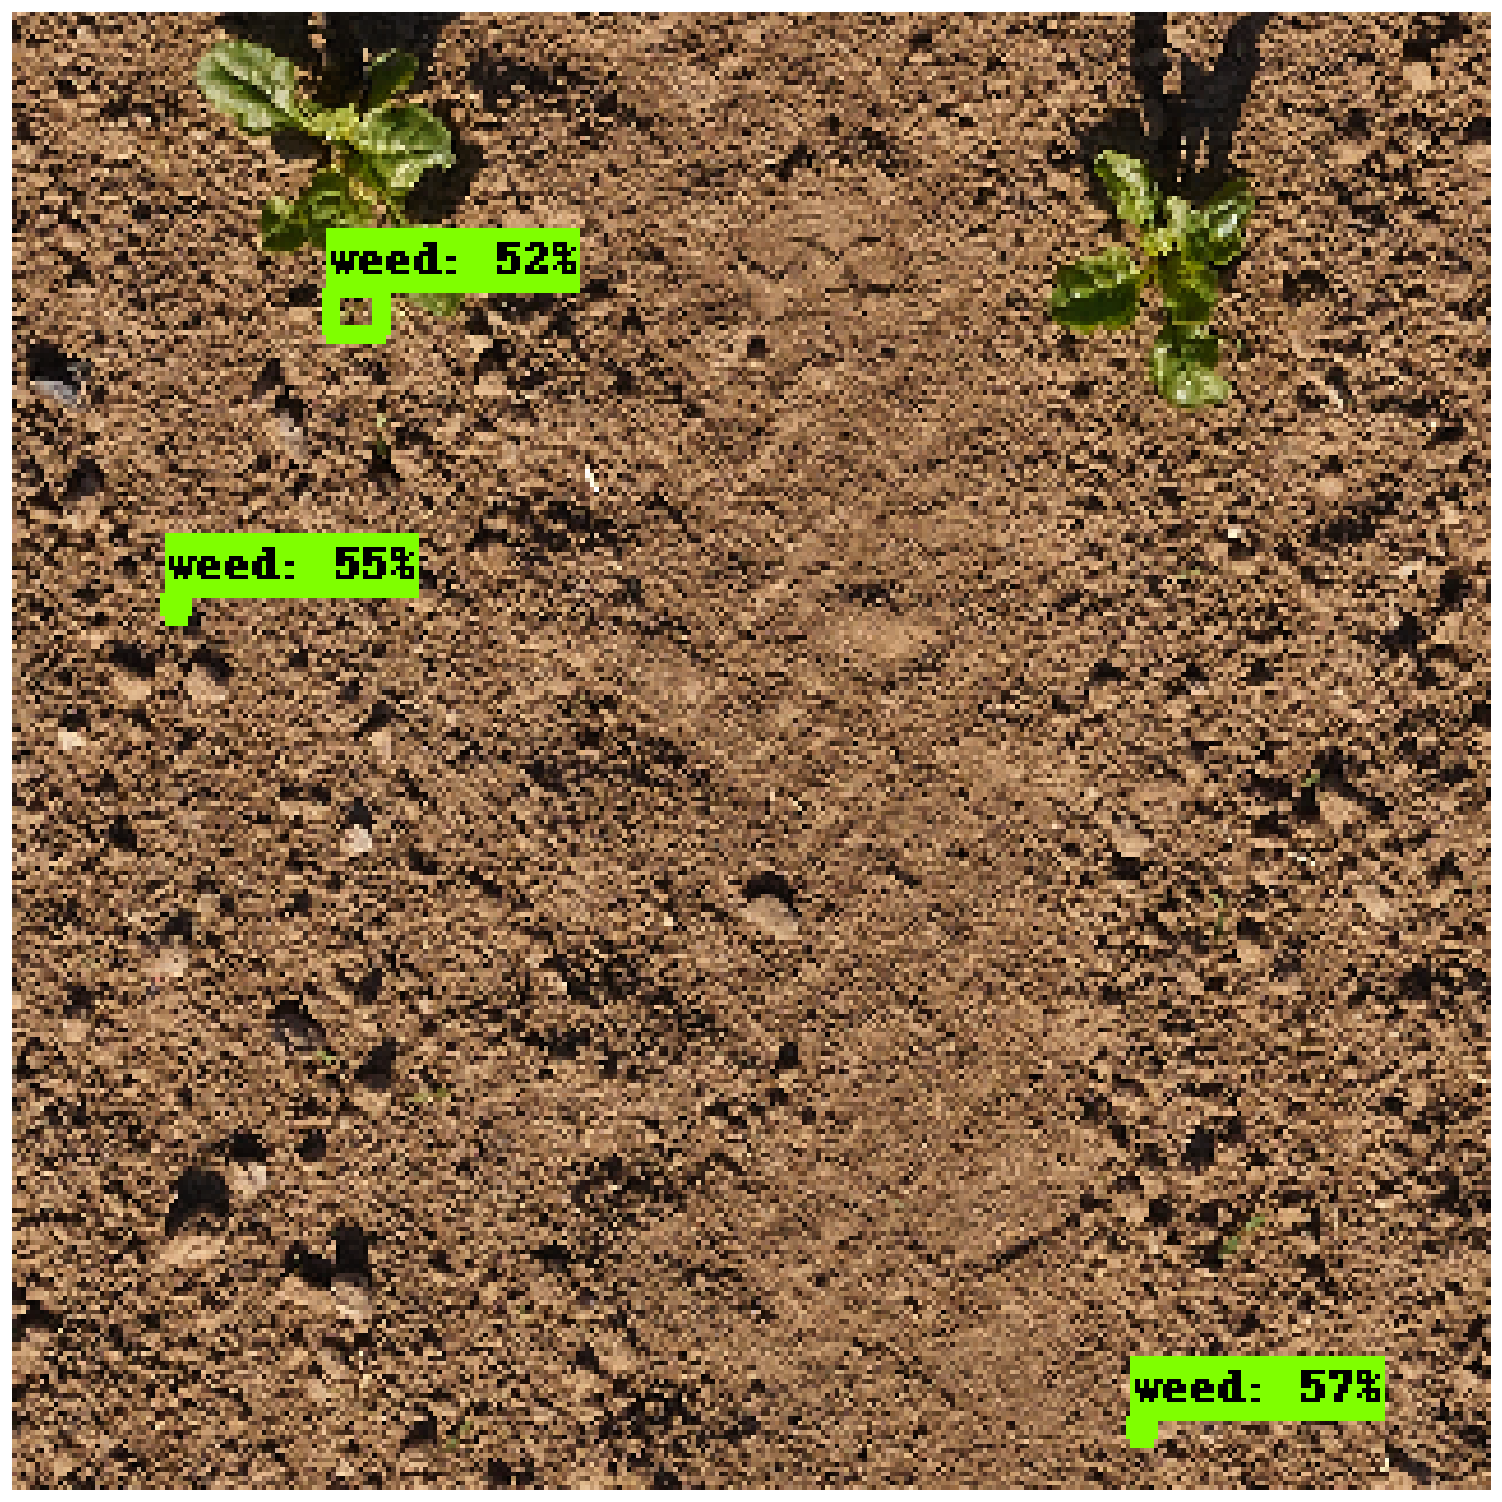

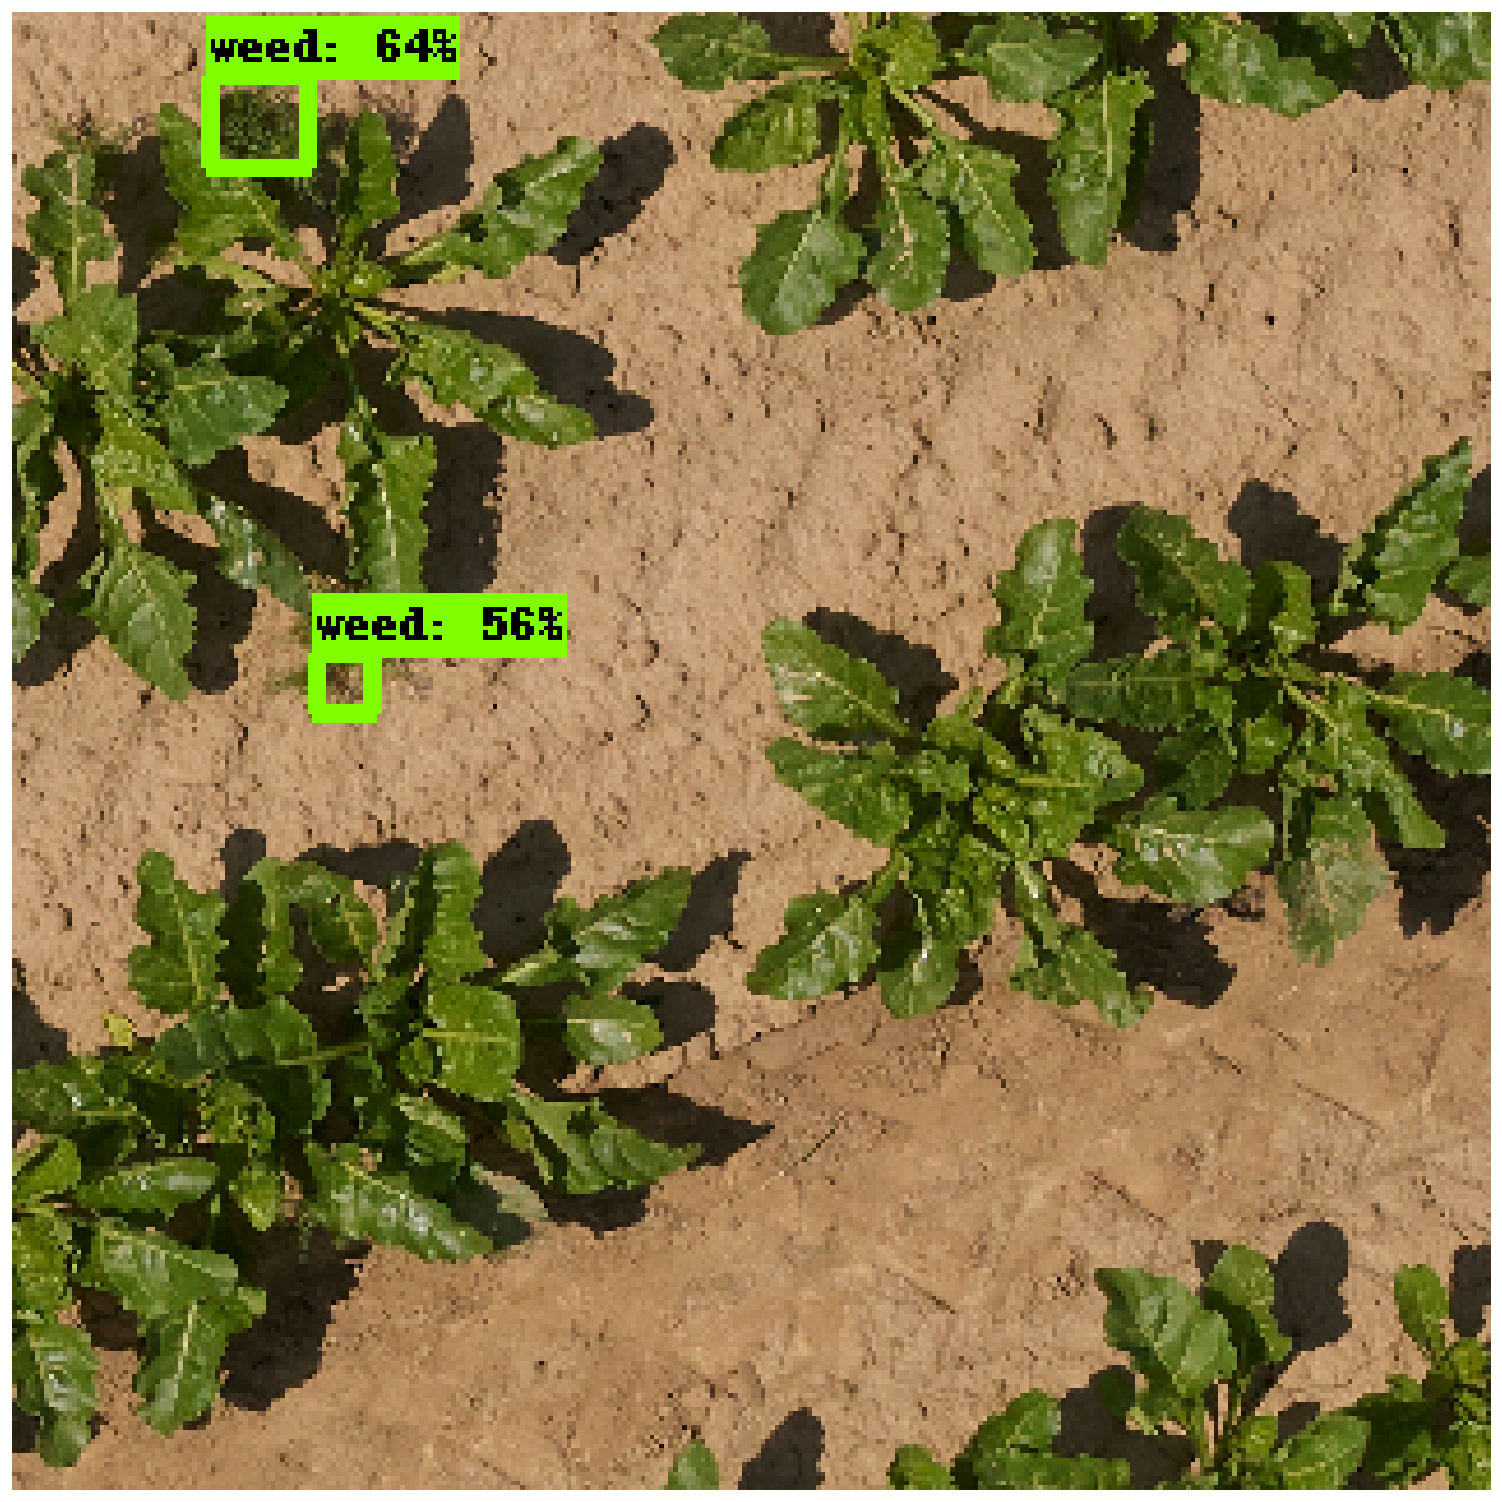

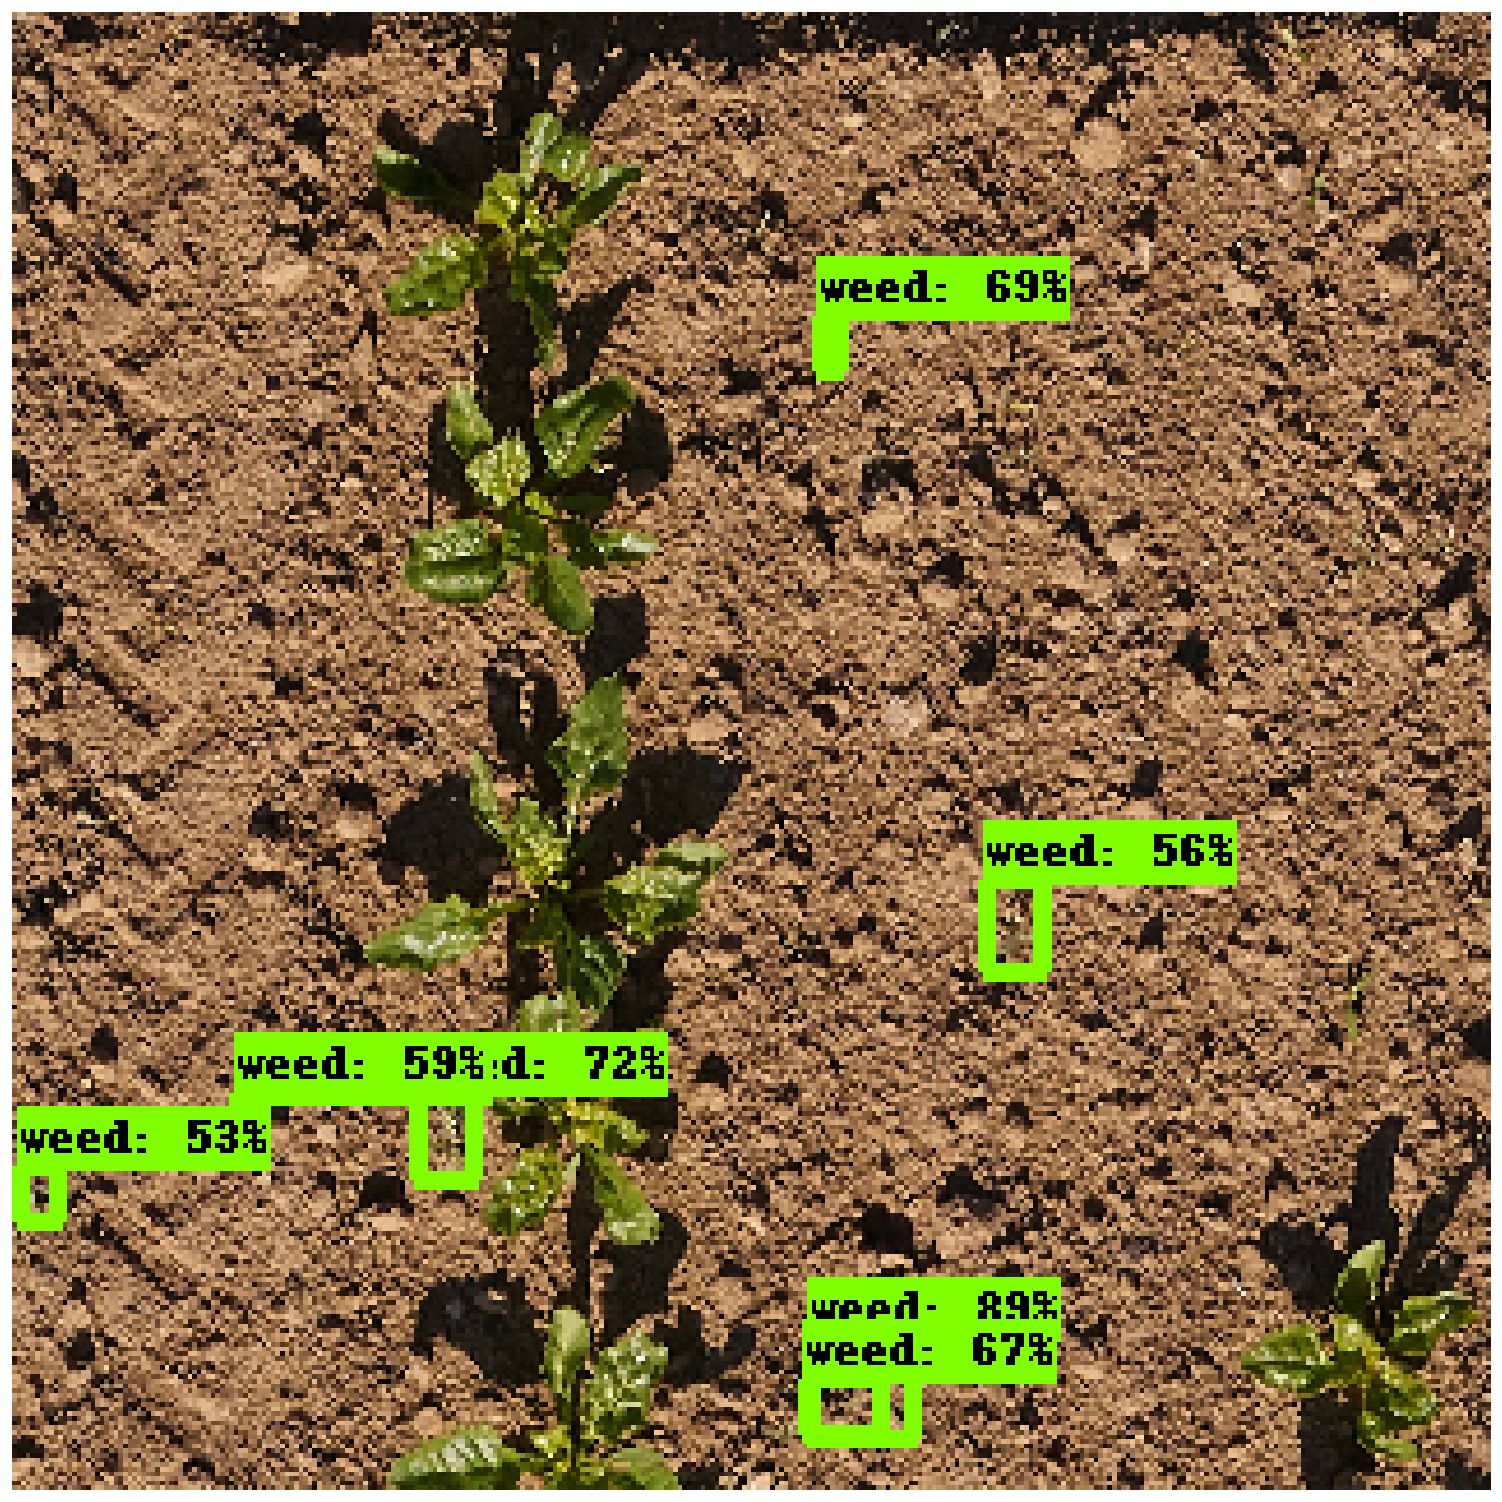

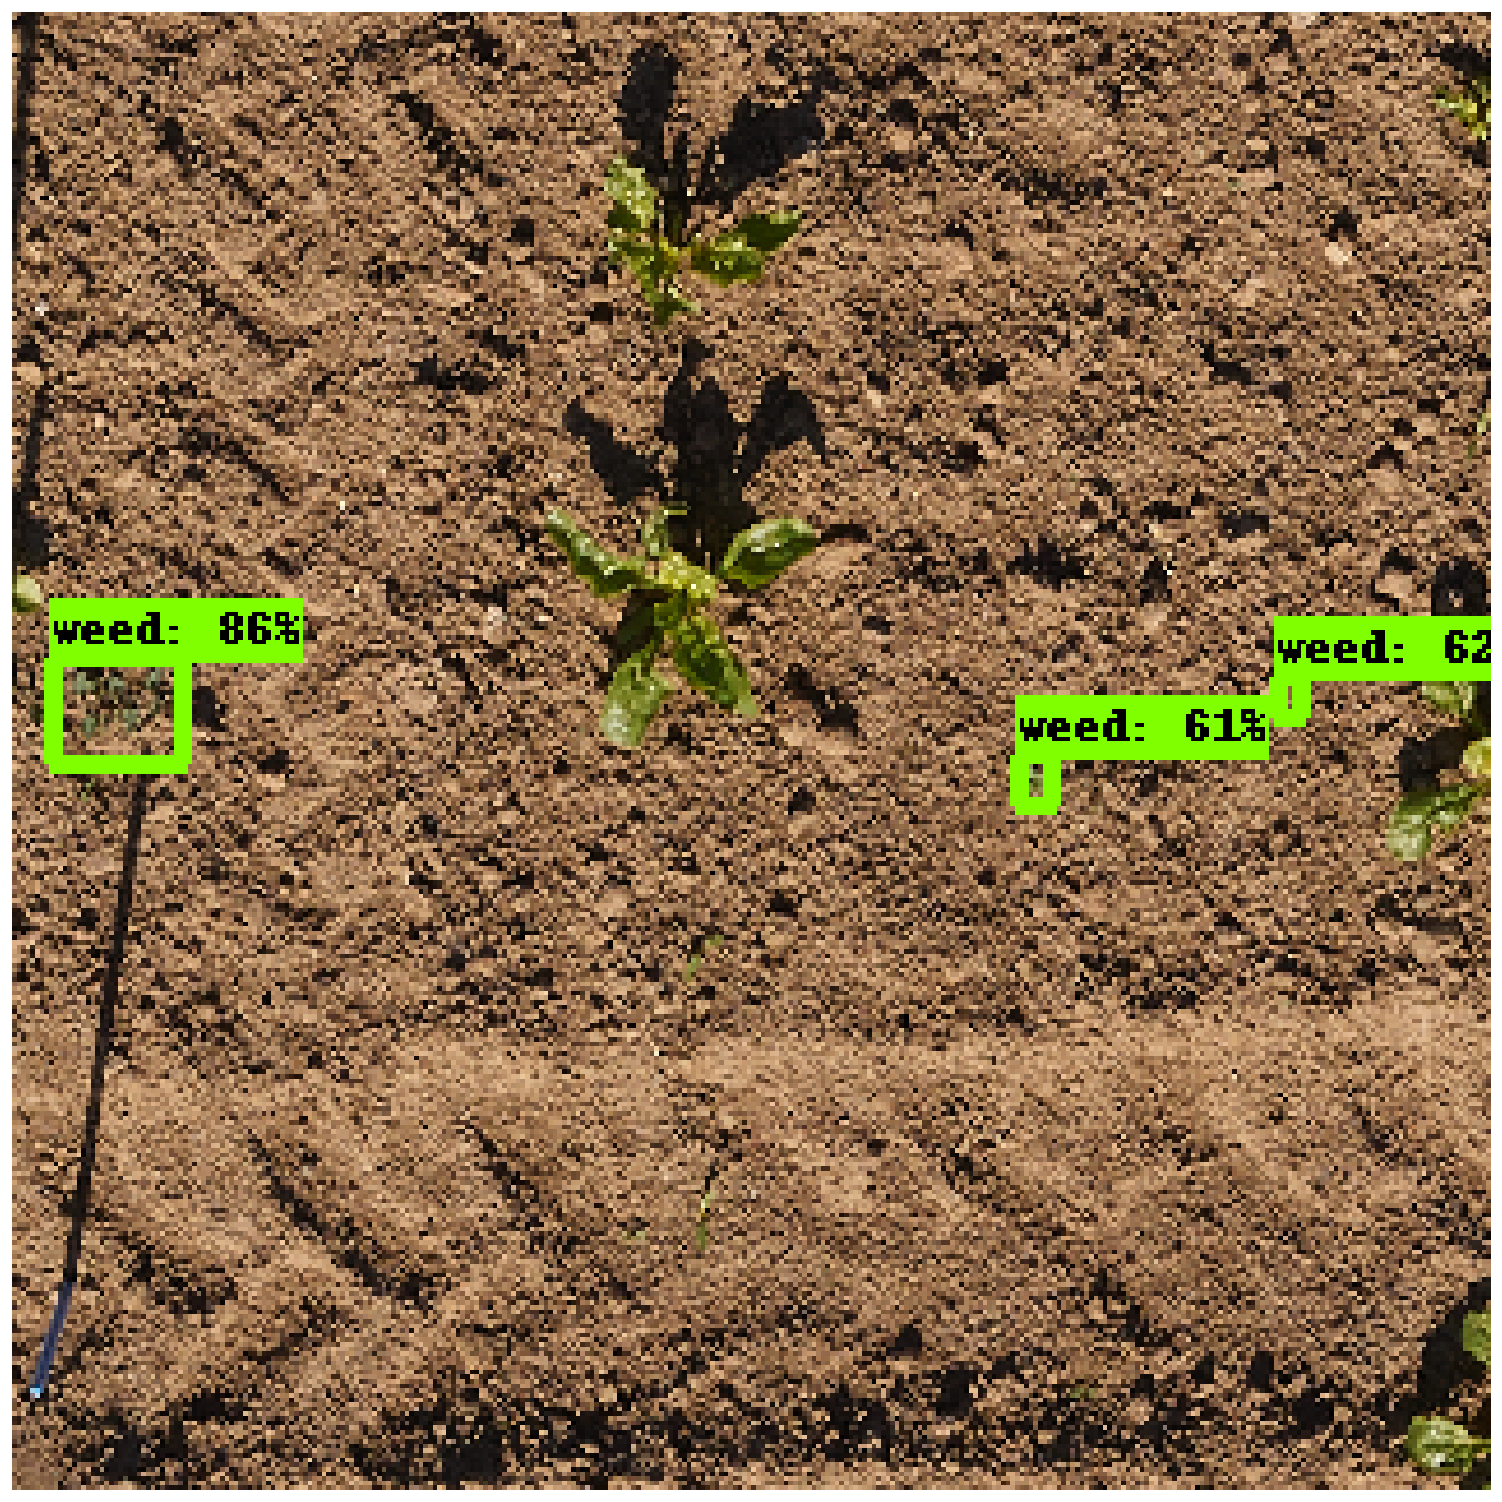

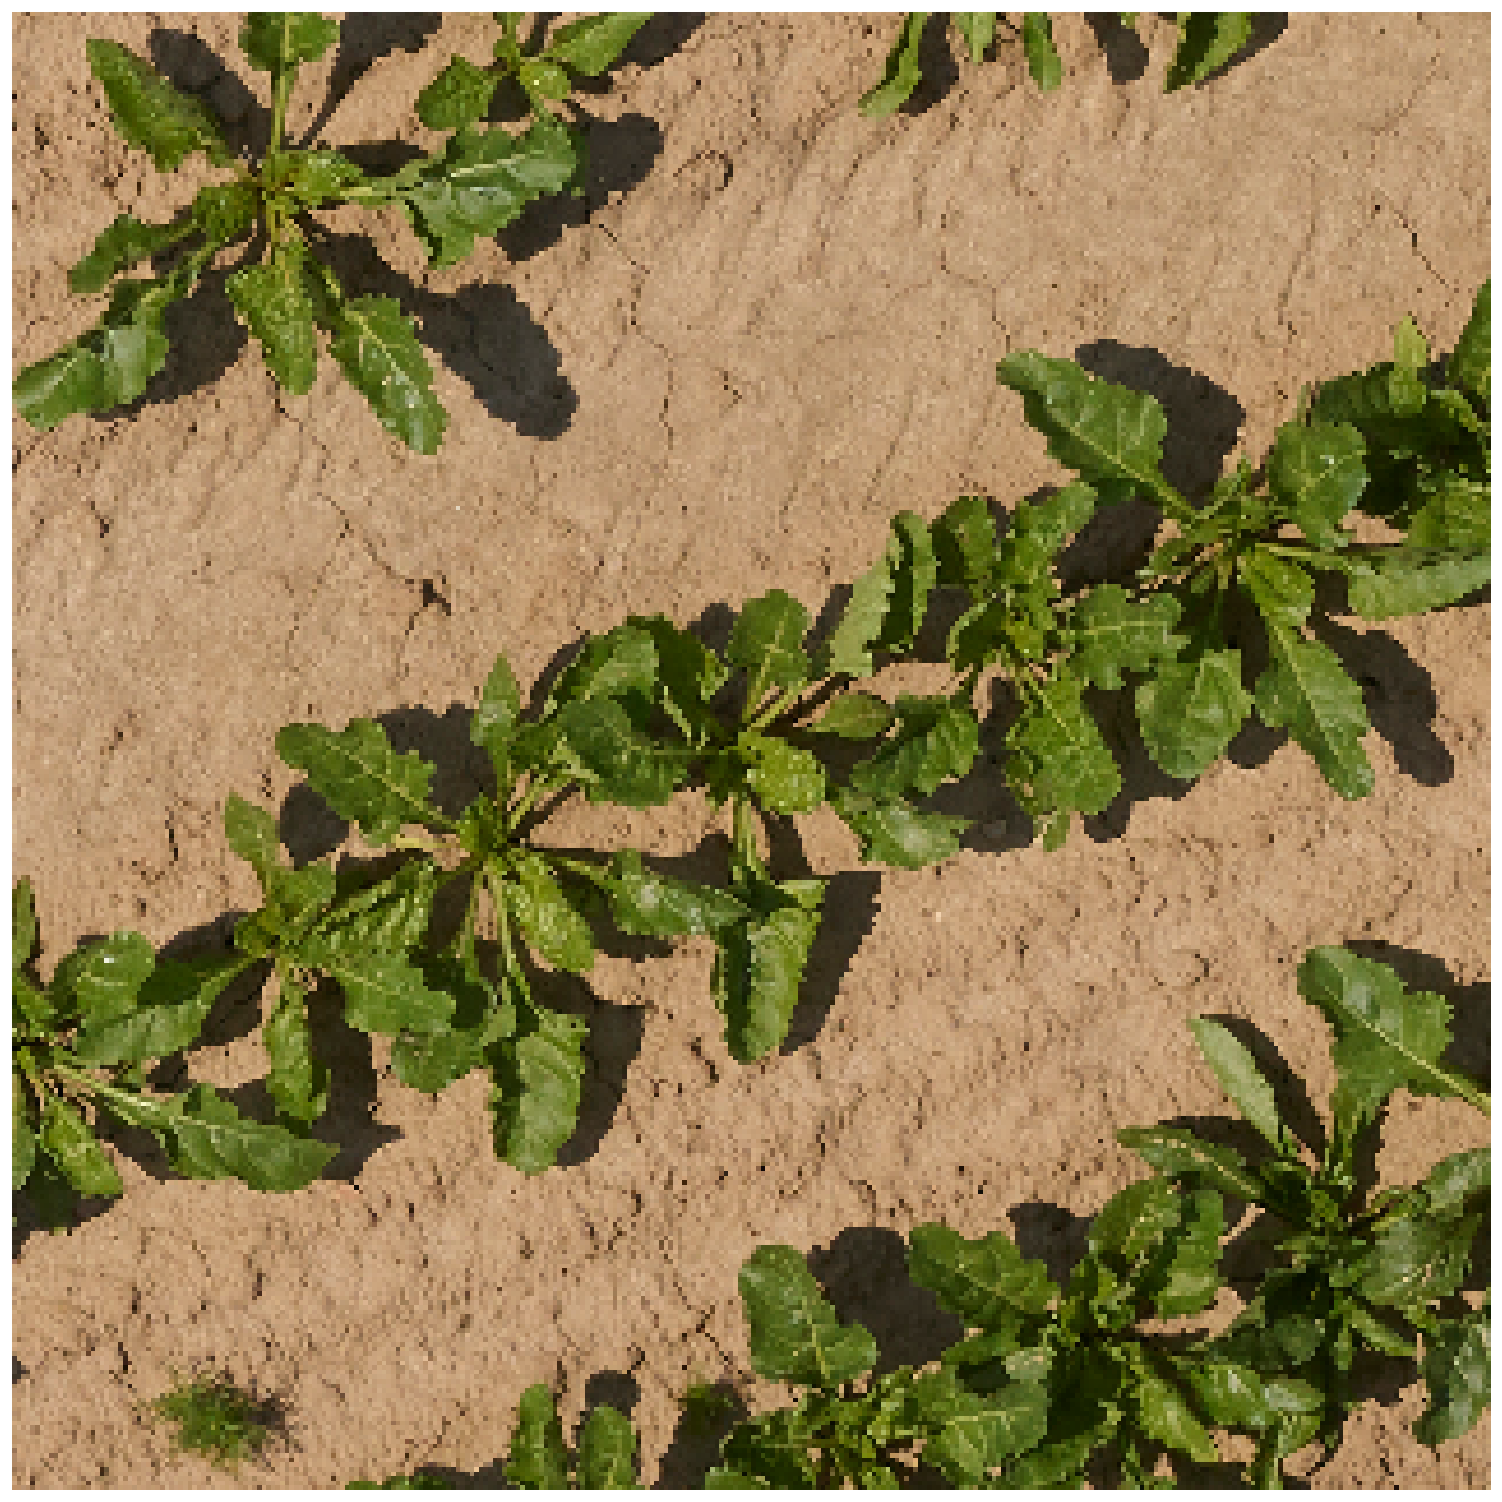

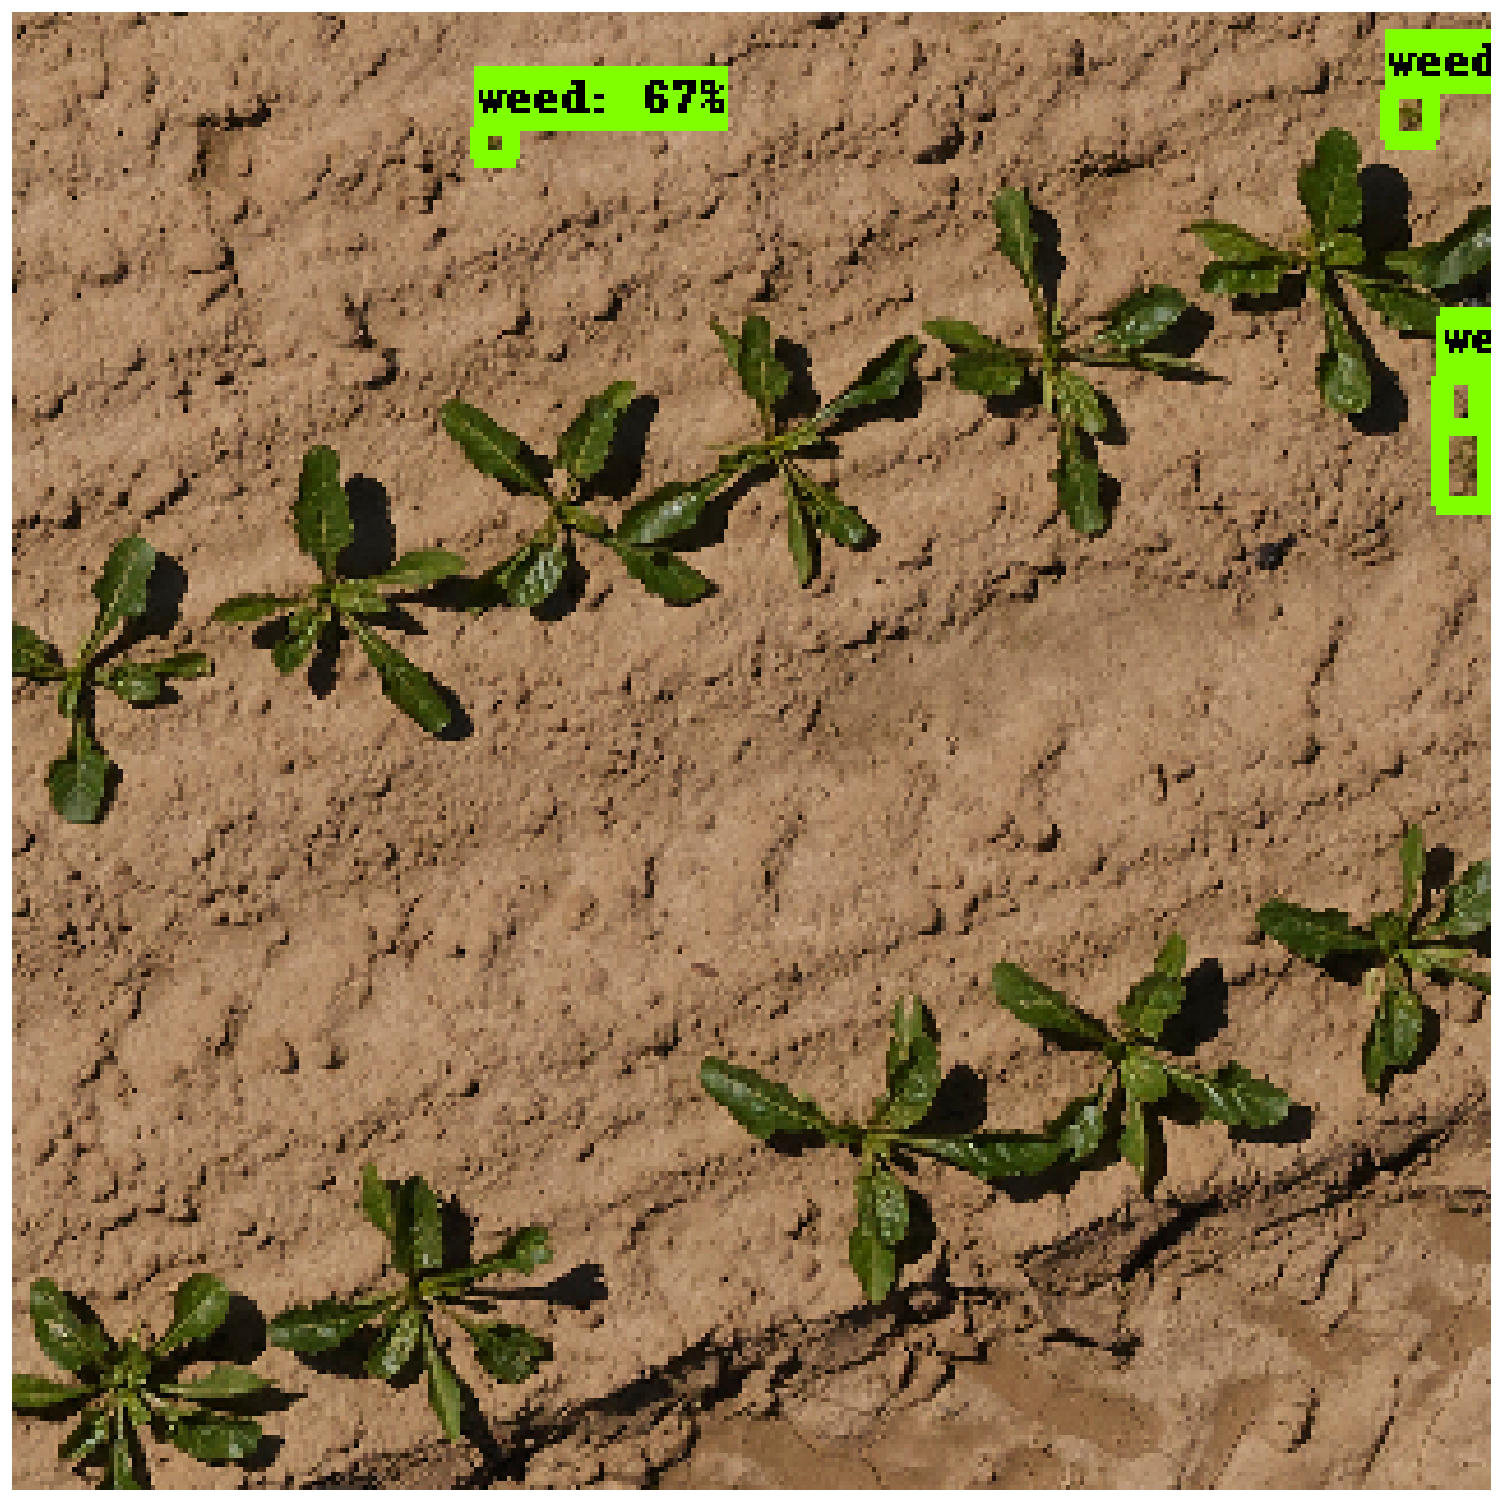

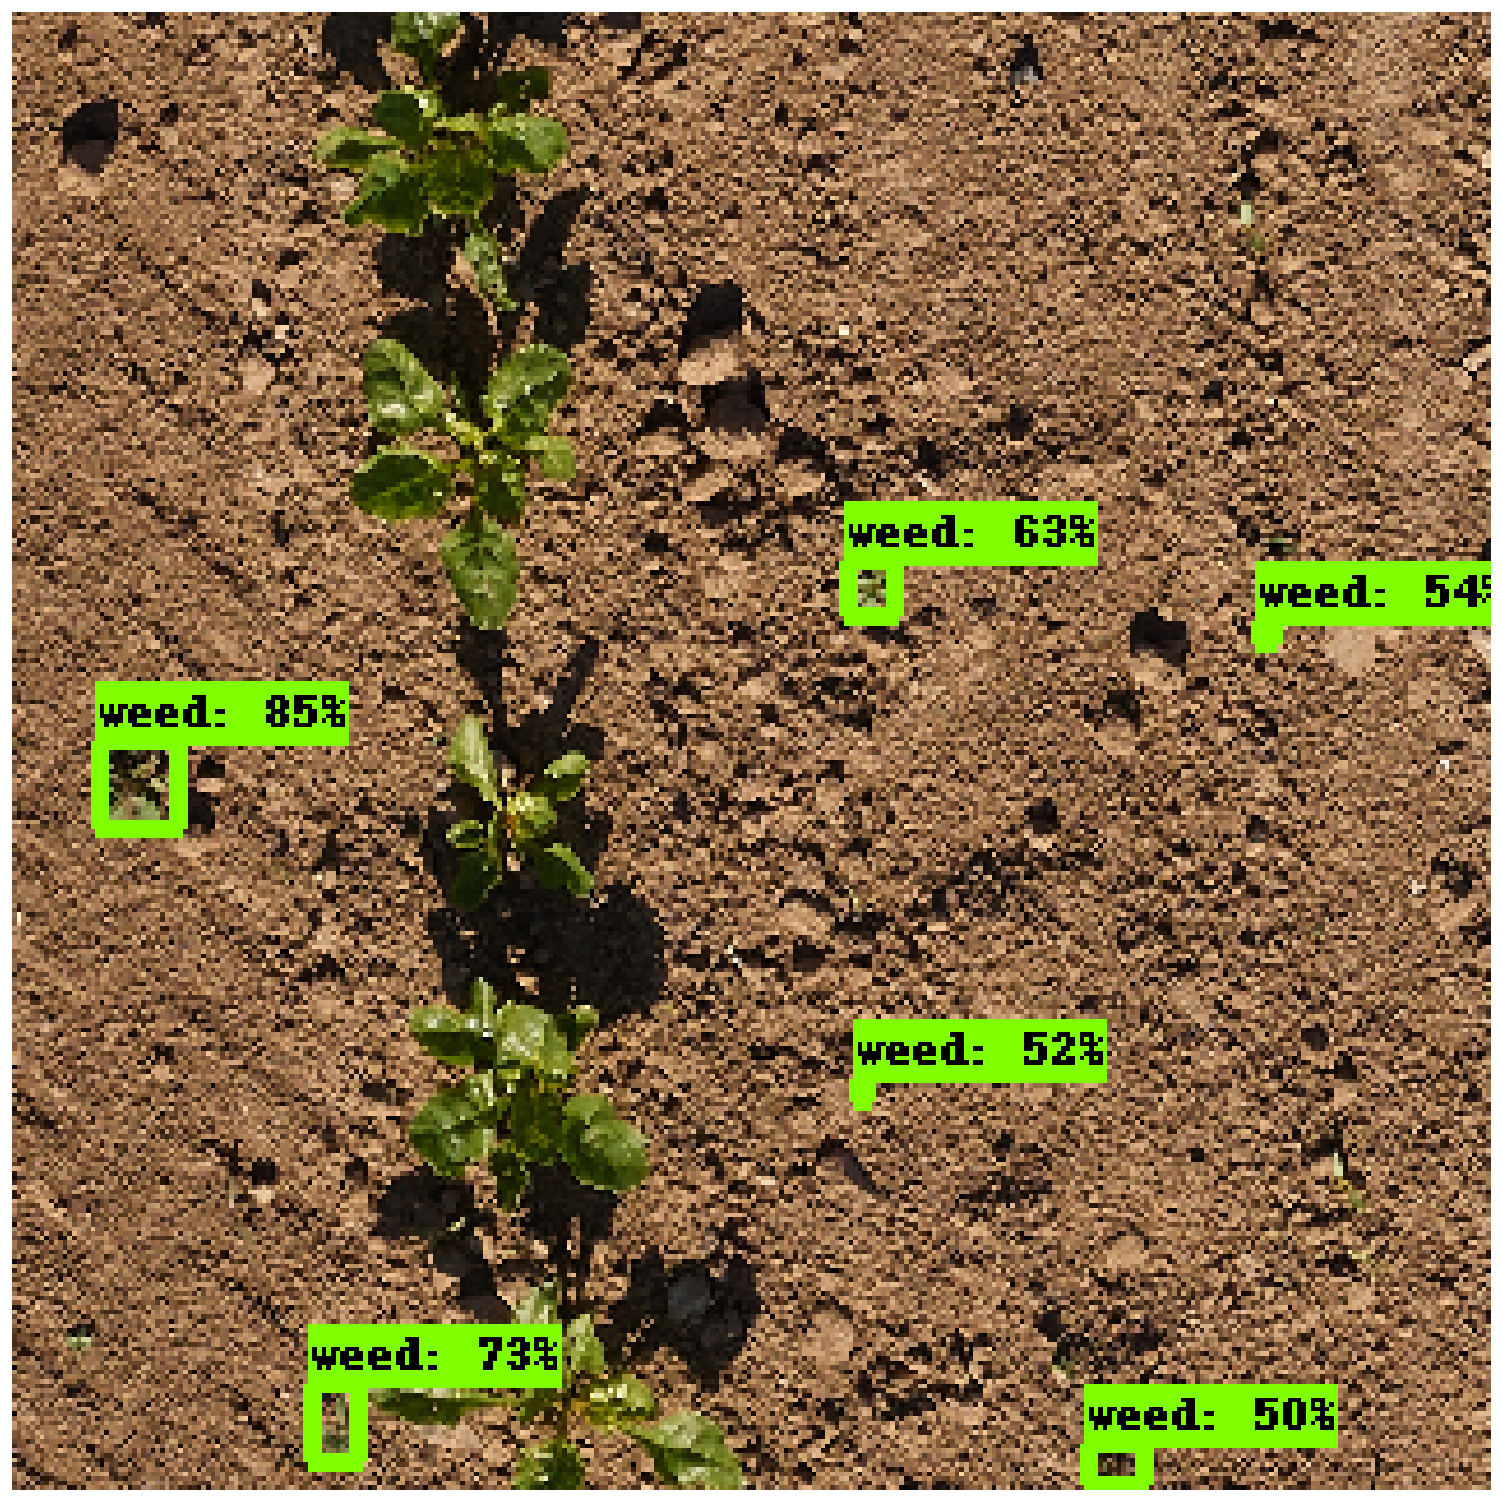

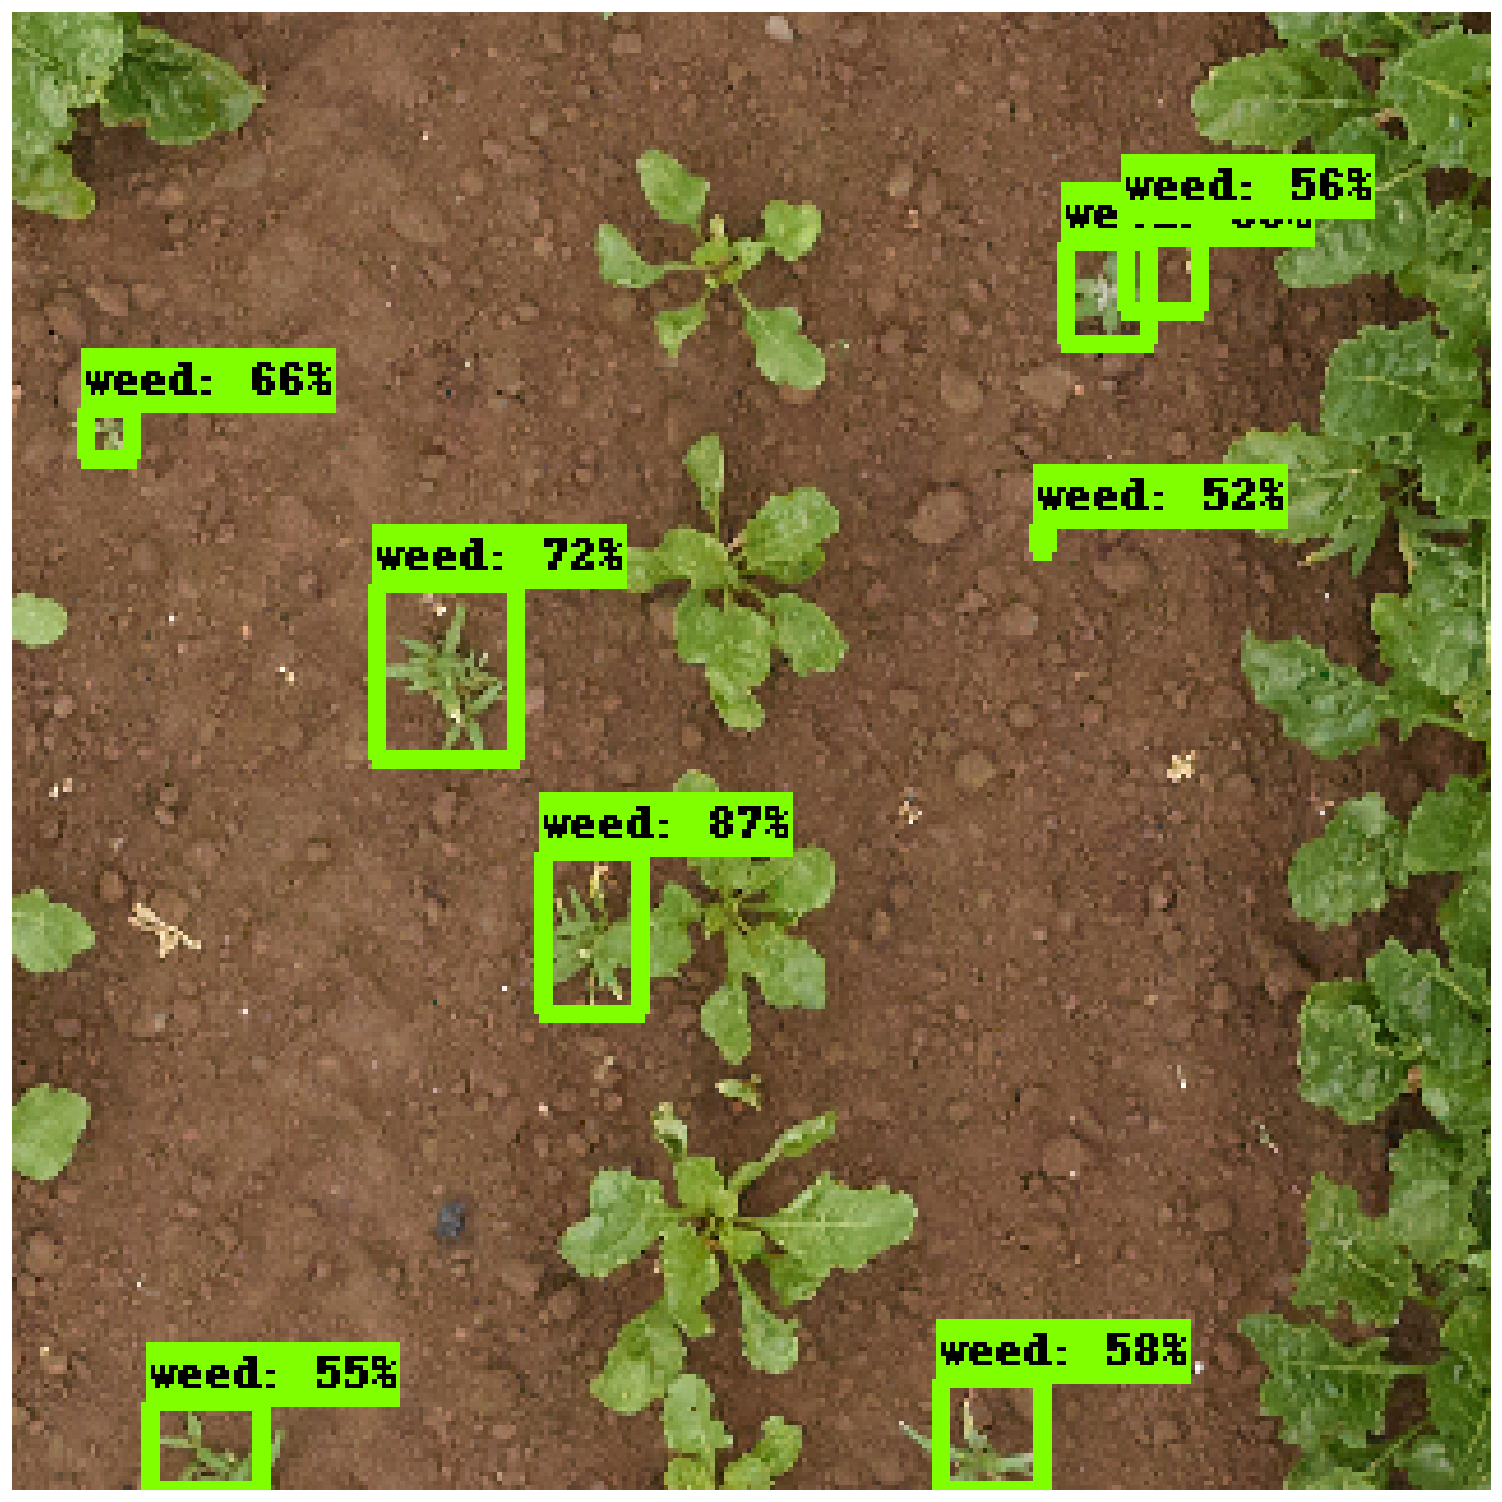

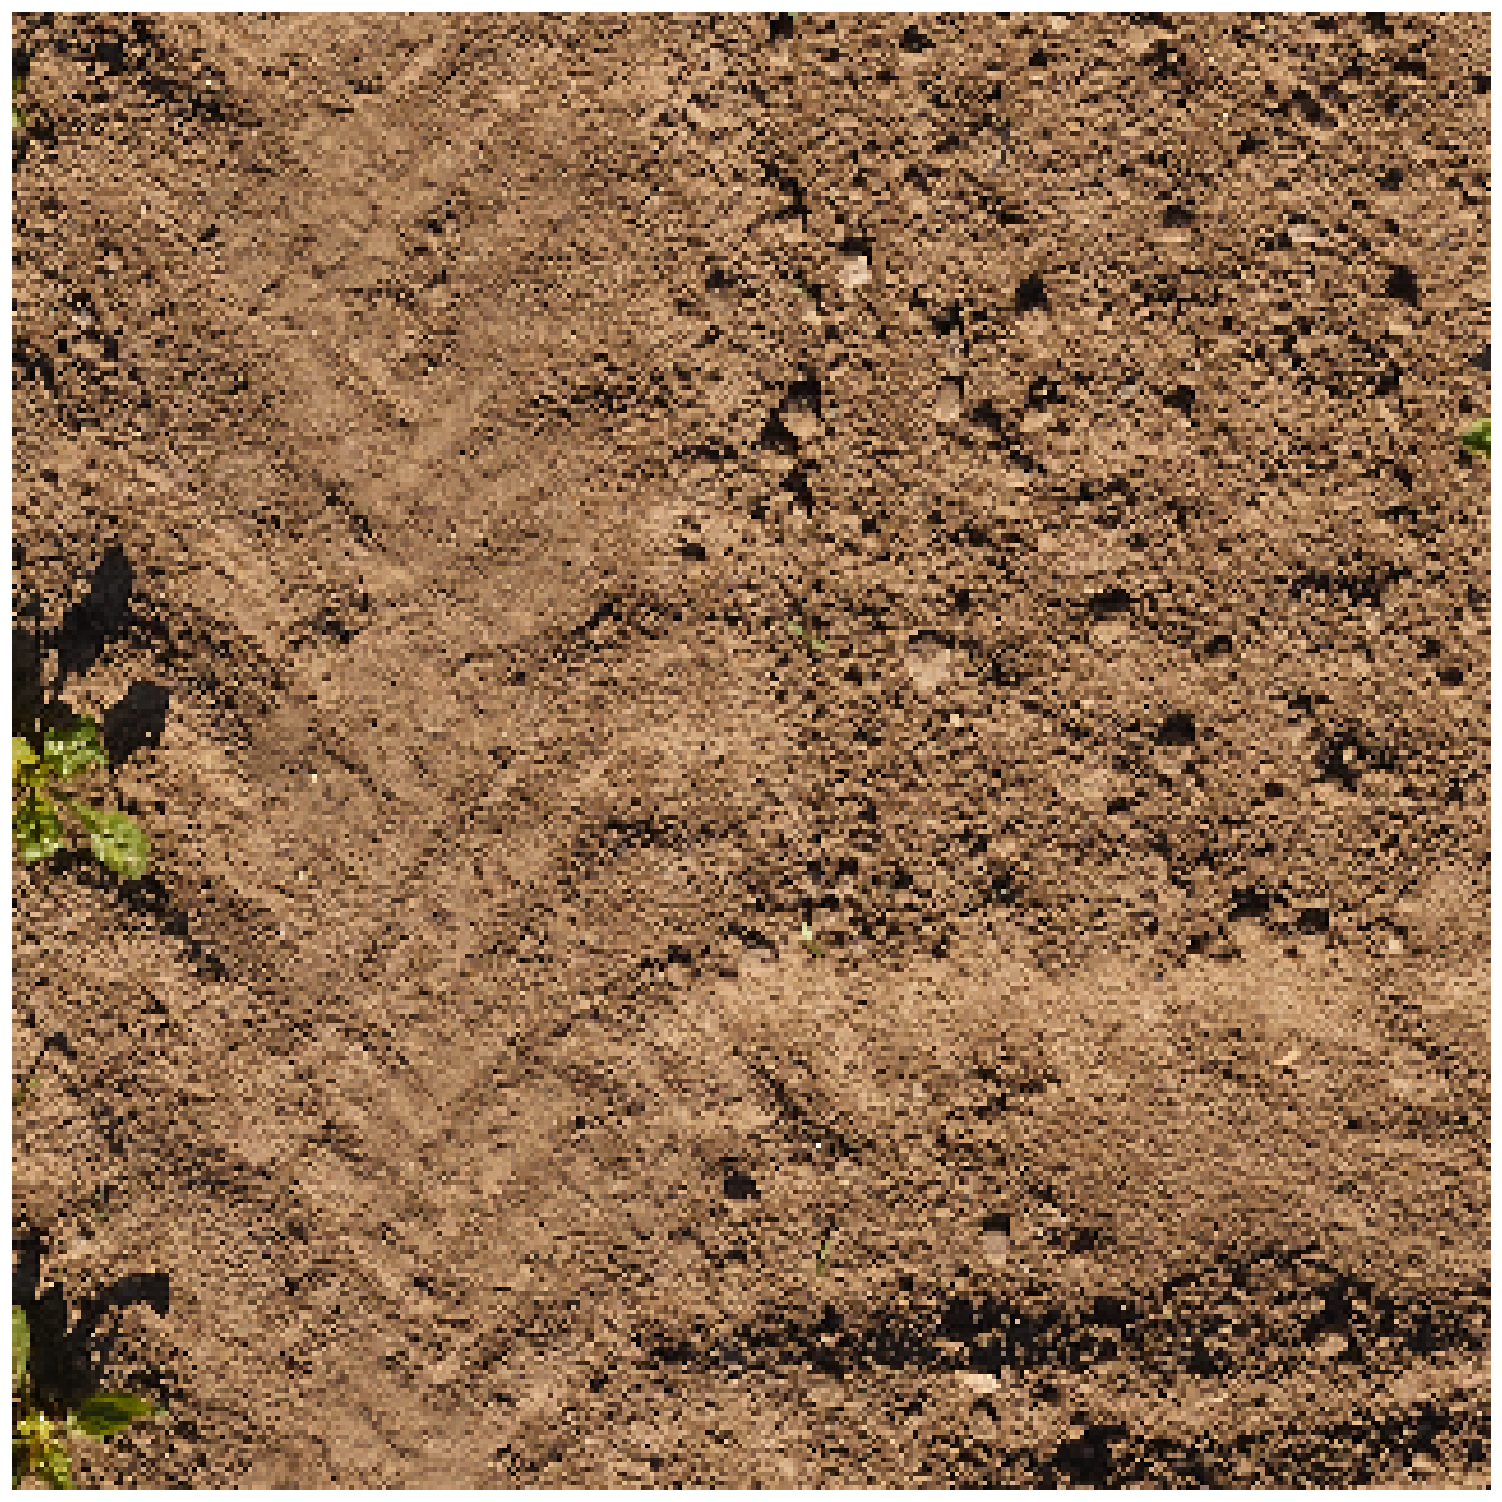

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(
    "/kaggle/working/exports/exported_model/saved_model"
)

category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:

    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=320,
        score_threshold=0.5,
        max_boxes=60,
    )
#     display(vis)

    plt.figure(figsize=(16, 16))

    plt.imshow(vis)

    plt.axis("off")

    plt.show()

    plt.close(fig)

## Discussion

The model demonstrates:

- Successful localization of plant instances
- Overlapping detections reduced via NMS
- Sensitivity to small objects (PhenoBench-specific challenge)

Limitations:
- Performance depends strongly on resolution (320×320)
- Dense scenes produce multiple candidate detections
- Further improvements possible via:
  - anchor tuning
  - longer training
  - quantization-aware training (QAT)

Future work:
- INT8 deployment via TFLite
- Real-time inference optimization